<a href="https://colab.research.google.com/github/AliRaddman/divar-ml-project/blob/main/notebooks/work/descriptive_ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" align="right">

# آمار توصیفی - بخش علی

در این نوت‌بوک، بخش مربوط به آمار توصیفی پروژه بررسی می‌شود.  
تمرکز فعلی روی تحلیل توزیع آگهی‌ها در دسته‌بندی‌های مختلف و سپس سؤال‌های مربوط به علی است.

</div>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

!pip install -q pyarrow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 6)

print("Setup completed.")

Mounted at /content/drive
Setup completed.


<div dir="rtl" align="right">

## خواندن فایل نهایی پیش‌پردازش‌شده

در این بخش، آخرین خروجی مرحله‌ی preprocessing را از Google Drive می‌خوانیم.  
این فایل شامل داده‌ی تمیزشده و ستون‌های ساخته‌شده در مراحل قبلی است.

</div>

In [2]:
data_path = "/content/drive/MyDrive/divar_project/cleaned_step3_geo.parquet"

df = pd.read_parquet(data_path)

print("Data loaded.")
print("Shape:", df.shape)
print("Number of columns:", len(df.columns))

df.head()

Data loaded.
Shape: (999943, 83)
Number of columns: 83


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,deed_type,has_business_deed,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,has_warehouse,has_parking,construction_year,is_rebuilt,has_warm_water_provider,has_heating_system,has_cooling_system,has_restroom,has_security_guard,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,property_type,regular_person_capacity,location_latitude,location_longitude,location_radius,created_at_shamsi,created_at_shamsi_readable,transaction_type,price_value_pos,rent_value_pos,credit_value_pos,building_size_pos,land_size_pos,area_for_unit_price,monthly_rent_equivalent,credit_equivalent,sale_price_per_m2,monthly_rent_equivalent_per_m2,credit_equivalent_per_m2,target_price,target_price_type,target_price_per_m2,is_valid_area_basic,is_valid_sale_price_basic,is_valid_rent_value_basic,is_valid_credit_value_basic,is_valid_target_price_basic,is_valid_area_q01_q99_by_cat3,is_valid_target_price_per_m2_q01_q99_by_cat3,is_valid_for_price_analysis,has_geo,is_valid_geo_basic,is_valid_geo_for_analysis,utm_easting,utm_northing,utm_zone_number,utm_zone_letter
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,500.0,NaN,<NA>,NaN,3.0,NaN,NaN,False,False,False,False,1395.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,4.0,35.811684,50.936600,500.0,1403-05,مرداد 1403,temporary_rent,NaN,NaN,NaN,500.0,NaN,500.0,NaN,NaN,NaN,NaN,NaN,NaN,not_defined,NaN,True,True,True,True,True,True,<NA>,False,True,True,True,494272.329998,3.963064e+06,39,S
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,60.0,NaN,<NA>,3.0,1.0,NaN,NaN,False,True,True,True,1384.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,500.0,1403-02,اردیبهشت 1403,sell,8.500000e+09,NaN,NaN,60.0,NaN,60.0,NaN,NaN,1.416667e+08,NaN,NaN,8.500000e+09,sale_total_price,1.416667e+08,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN,26000000.0,NaN,NaN,132.0,NaN,<NA>,3.0,3.0,NaN,NaN,False,True,True,True,1401.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,35.703865,51.373459,NaN,1403-07,مهر 1403,rent,NaN,26000000.0,750000000.0,132.0,NaN,132.0,48500000.0,1.616667e+09,NaN,3.674242e+05,1.224747e+07,4.850000e+07,monthly_rent_equivalent,3.674242e+05,True,True,True,True,True,True,True,True,True,True,True,533784.424602,3.951168e+06,39,S
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN,95000000.0,NaN,NaN,90.0,NaN,<NA>,4.0,1.0,NaN,NaN,False,True,False,True,1400.0,False,NaN,NaN,NaN,NaN,False,False,NaN,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,1403-03,خرداد 1403,rent,NaN,95000000.0,950000000.0,90.0,NaN,90.0,123500000.0,4.116667e+09,NaN,1.372222e+06,4.574074e+07,1.235000e+08,monthly_rent_equivalent,1.372222e+06,True,True,True,True,True,True,True,True,False,<NA>,False,NaN,NaN,<NA>,<NA>
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,115.

<div dir="rtl" align="right">

## بررسی ستون‌های دسته‌بندی

در سؤال اول آمار توصیفی، باید توزیع آگهی‌ها را بر اساس دسته‌بندی سطح دو و سطح سه بررسی کنیم.  
برای این کار ابتدا وضعیت ستون‌های زیر را چک می‌کنیم:

`cat2_slug`

`cat3_slug`

</div>

In [3]:
category_cols = ["cat2_slug", "cat3_slug"]

print("Missing values:")
print(df[category_cols].isna().sum())

print("\nUnique values:")
print(df[category_cols].nunique())

print("\ncat2_slug values:")
print(df["cat2_slug"].value_counts())

print("\nTop 20 cat3_slug values:")
print(df["cat3_slug"].value_counts().head(20))

Missing values:
cat2_slug    0
cat3_slug    0
dtype: int64

Unique values:
cat2_slug     6
cat3_slug    16
dtype: int64

cat2_slug values:
cat2_slug
residential-sell        558692
residential-rent        276528
commercial-rent          76564
commercial-sell          38860
temporary-rent           29897
real-estate-services     19402
Name: count, dtype: int64

Top 20 cat3_slug values:
cat3_slug
apartment-sell                        303372
apartment-rent                        211853
plot-old                              133570
house-villa-sell                      121750
house-villa-rent                       64675
shop-rent                              45993
shop-sell                              21855
office-rent                            21416
suite-apartment                        16460
presell                                15780
villa                                  12898
industry-agriculture-business-sell     11850
industry-agriculture-business-rent      9155
office-sell       

<div dir="rtl" align="right">

## محاسبه تعداد و درصد آگهی‌ها در هر دسته

در این بخش، تعداد آگهی‌های هر دسته را برای دسته‌بندی سطح دو و سطح سه محاسبه می‌کنیم.  
علاوه بر تعداد، درصد سهم هر دسته از کل داده‌ها نیز محاسبه می‌شود تا مقایسه دسته‌ها راحت‌تر باشد.

</div>

In [4]:
def category_distribution(data, column_name):
    counts = data[column_name].value_counts()
    percents = data[column_name].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        column_name: counts.index,
        "count": counts.values,
        "percent": percents.values
    })

    result["percent"] = result["percent"].round(2)

    return result


cat2_distribution = category_distribution(df, "cat2_slug")
cat3_distribution = category_distribution(df, "cat3_slug")

print("cat2_slug distribution:")
display(cat2_distribution)

print("\ncat3_slug distribution:")
display(cat3_distribution)

cat2_slug distribution:


,cat2_slug,count,percent
0,residential-sell,558692,55.87
1,residential-rent,276528,27.65
2,commercial-rent,76564,7.66
3,commercial-sell,38860,3.89
4,temporary-rent,29897,2.99
5,real-estate-services,19402,1.94



cat3_slug distribution:


,cat3_slug,count,percent
0,apartment-sell,303372,30.34
1,apartment-rent,211853,21.19
2,plot-old,133570,13.36
3,house-villa-sell,121750,12.18
4,house-villa-rent,64675,6.47
5,shop-rent,45993,4.60
6,shop-sell,21855,2.19
7,office-rent,21416,2.14
8,suite-apartment,16460,1.65
9,presell,15780,1.58


<div dir="rtl" align="right">

## نمودار توزیع آگهی‌ها بر اساس دسته‌بندی سطح دو

در این بخش، تعداد آگهی‌ها را در هر مقدار از ستون `cat2_slug` رسم می‌کنیم.  
این نمودار نشان می‌دهد داده بیشتر از چه نوع آگهی‌هایی تشکیل شده است.

</div>

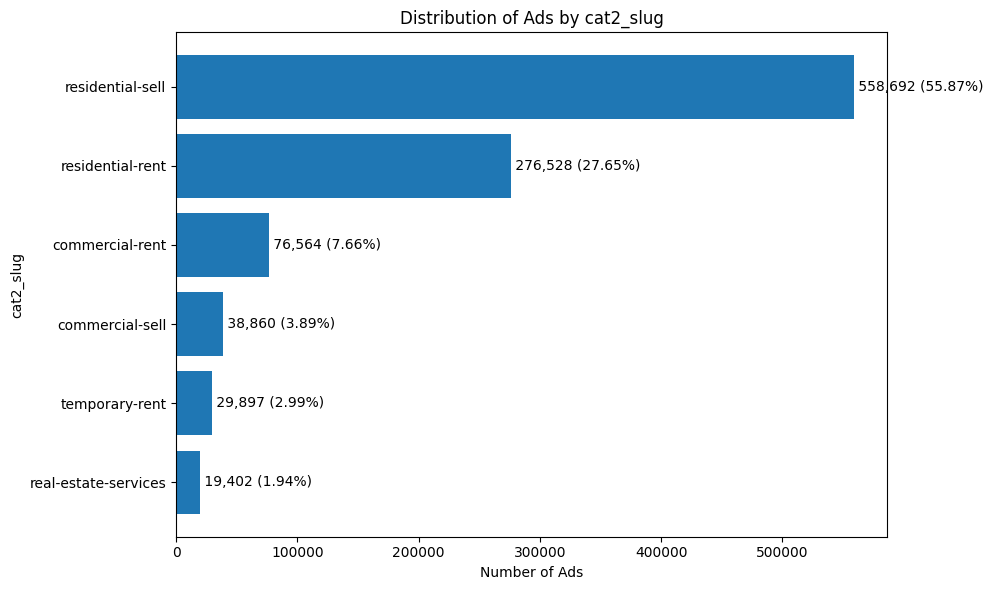

In [5]:
cat2_plot_data = cat2_distribution.sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(cat2_plot_data["cat2_slug"], cat2_plot_data["count"])

plt.title("Distribution of Ads by cat2_slug")
plt.xlabel("Number of Ads")
plt.ylabel("cat2_slug")

for index, row in cat2_plot_data.iterrows():
    plt.text(
        row["count"],
        row["cat2_slug"],
        f' {row["count"]:,} ({row["percent"]}%)',
        va="center"
    )

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نمودار توزیع آگهی‌ها بر اساس دسته‌بندی سطح سه

در این بخش، تعداد آگهی‌ها را در هر مقدار از ستون `cat3_slug` رسم می‌کنیم.  
چون تعداد دسته‌های سطح سه فقط `16` مورد است، همه‌ی دسته‌ها را در نمودار نمایش می‌دهیم.

</div>

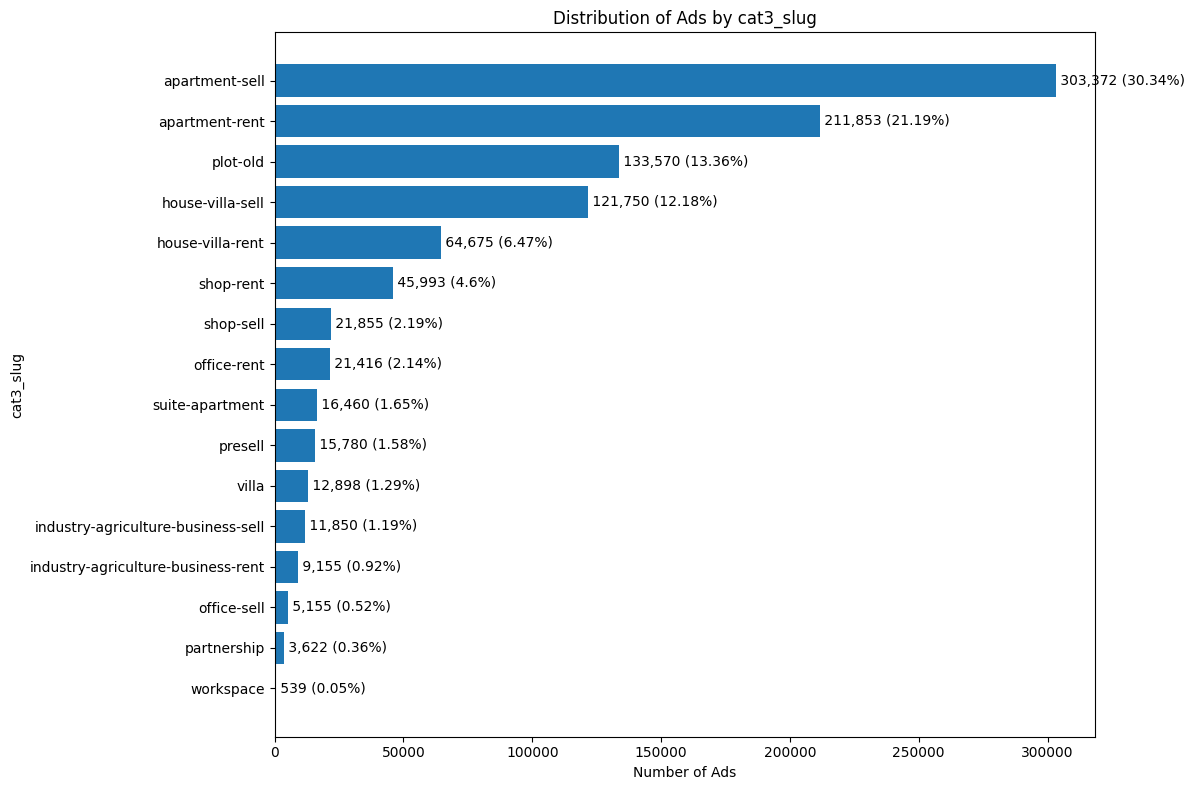

In [6]:
cat3_plot_data = cat3_distribution.sort_values("count", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(cat3_plot_data["cat3_slug"], cat3_plot_data["count"])

plt.title("Distribution of Ads by cat3_slug")
plt.xlabel("Number of Ads")
plt.ylabel("cat3_slug")

for index, row in cat3_plot_data.iterrows():
    plt.text(
        row["count"],
        row["cat3_slug"],
        f' {row["count"]:,} ({row["percent"]}%)',
        va="center"
    )

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

### تحلیل توزیع آگهی‌ها در دسته‌بندی‌ها

در دسته‌بندی سطح دو، بیشترین تعداد آگهی‌ها مربوط به دسته‌ی

`residential-sell`

است که حدود

`55.87%`

از کل داده‌ها را تشکیل می‌دهد. بعد از آن دسته‌ی

`residential-rent`

با حدود

`27.65%`

قرار دارد. بنابراین بخش عمده‌ی دیتاست مربوط به آگهی‌های مسکونی، مخصوصاً فروش مسکونی است.

در دسته‌بندی سطح سه نیز بیشترین سهم مربوط به

`apartment-sell`

با حدود

`30.34%`

و سپس

`apartment-rent`

با حدود

`21.19%`

است. این موضوع نشان می‌دهد که آگهی‌های آپارتمان، چه برای فروش و چه برای اجاره، بخش غالب دیتاست را تشکیل می‌دهند.

همچنین دسته‌هایی مثل

`workspace`

و

`partnership`

سهم بسیار کمی از داده دارند. بنابراین در تحلیل‌های بعدی و مخصوصاً مدل‌سازی، باید به نامتوازن بودن توزیع دسته‌ها توجه شود؛ زیرا نتایج کلی ممکن است بیشتر تحت تأثیر دسته‌های پرتعداد مثل آپارتمان فروش و آپارتمان اجاره قرار بگیرد.

</div>